# Lab 4: Parabolic problems

On the unit square domain $\Omega = (0,1) \times (0,1)$ and time interval $I = (0, 1)$ 
  we consider the initial and boundary value problem
  $$
    \begin{cases}
      \dfrac{\partial u}{\partial t}- \Delta u = f  & \text{in } \Omega\times I, \\
      u = g                                         & \text{on } \partial\Omega\times I, \\
      {\left. u \right|}_{t=0} = u_0                & \text{on } \Omega. \\
    \end{cases}
$$

## Weak formulations

Let $\tilde{u}= u - u_g$, with $u_g\in H^1(\Omega)$ such that $(u_g)_{|\partial\Omega}=g$ (well defined assuming sufficient regularity for the boundary data $g$). Thus $\tilde{u}(\cdot,t)\in H^1_0(\Omega)$ for all $t>0$ solve the parabolic problem 
  $$
    \begin{cases}
      \dfrac{\partial \tilde{u}}{\partial t}- \Delta \tilde{u} = f + \Delta u_g  & \text{in } L^2(I;H^{-1}(\Omega)), \\
      \tilde{u} = 0                                         & \text{a.e. on } \partial\Omega\times I, \\
      {\left. \tilde{u} \right|}_{t=0} = u_0-u_g                & \text{in } L^2(\Omega). \\
    \end{cases}
$$


For the sake of simplicity in the notation, we rename $\tilde{u}$ with $u$, remembering that in the end the solution to the original problem will be $u + u_g$. Multiplying by a test function $v\in H^1_0(\Omega)$ and integrating by parts in both sides of the first equation yields
$$
  \int_{\Omega} \dfrac{\partial u}{\partial t} v  \, d\boldsymbol{x} +
  \int_\Omega \boldsymbol{\nabla}u \cdot \boldsymbol{\nabla} v \, d\boldsymbol{x} =
  \int_\Omega f v \, d\boldsymbol{x}
  -\int_\Omega \boldsymbol{\nabla}u_g \cdot \boldsymbol{\nabla} v \, d\boldsymbol{x}.
$$

We denote by $(\cdot,\cdot)_\Omega$ the inner product in $L^2(\Omega)$ and we introduce the bilinear form $a:H^1_0(\Omega)\times H^1_0(\Omega)\to\mathbb{R}$ such that
$ a(u,v) :=  \int_\Omega \boldsymbol{\nabla}u \cdot \boldsymbol{\nabla} v \, d\boldsymbol{x}$. Hence, we can rewrite the previous relation as
$$
\dfrac{\partial}{\partial t} (u,v)_\Omega + a(u,v) =
(f,v)_\Omega - a(u_g,v) \in L^2(I). 
$$
Notice that the previous relation together with the initial condition correspond to an initial value problem (Cauchy problem).

#### Semi-discrete in time weak form

Let's consider a uniform subdivision of the time interval $I$ into $N$ subintervals of length $\delta t$. For conciseness, we adopt the notation $u_n= u(n\ \delta t)$ and $f_n= f(n\ \delta t)$ for all $n\in\{ 0, N\}$.
Discretizing the time derivative by the $\theta$-method, i.e.
      $$
        \frac{\partial u}{\partial t} = A u + f
        \quad\rightarrow\quad
        \frac{u_{n+1} - u_{n}}{\delta t} =
          \theta A u_{n+1} + (1 - \theta) A u_{n} +
          \theta f_{n+1} + (1 - \theta) f_n,
      $$
leads to
$$
\left(\frac{u_{n+1} - u_{n}}{\delta t},v \right)_\Omega
+\theta a(u_{n+1},v) + (1-\theta) a(u_n,v) =
\left(\theta f_{n+1} + (1-\theta) f_n,v\right)_\Omega -a(u_g,v) \quad \forall n\in\{ 1, N\},
$$
with $u_0$ given by the initial condition. 

Rearranging the previous equation, we obtain the semi-discrete formulation: For all $n\in\{ 0, N-1\}$, find $u_{n+1}$ such that
$$
(u_{n+1},v)_\Omega + \delta t\theta\ a(u_{n+1},v)=
(u_{n},v)_\Omega + \delta t(\theta-1)\ a(u_{n},v)+
\delta t \left(\theta f_{n+1} + (1-\theta) f_n,v\right)_\Omega -\delta t\ a(u_g,v).
$$

#### **Exercise**: Establish the well-posedness of (one step of) the previous formulation resorting to the Lax-Milgram lemma. 

#### Space-time weak formulation

If we aim at deriving a weak formulation also in time, we can multiply both sides of the latter by a sufficiently regular test function $\phi:I\to\mathbb{R}$ (for instance $\phi\in H^1(I)$). Hence, multiplying by such $\phi$ and integrating by parts in time, we get
$$
\frac12\int_0^1 \dfrac{\partial}{\partial t}\left[(u,v)_\Omega\phi\right] \,dt 
-\frac12\int_0^1(u,v)_\Omega \dfrac{\partial\phi}{\partial t} \,dt + \frac12\int_0^1 \left(\dfrac{\partial u}{\partial t},v\right)_\Omega \phi\, dt
+ \int_0^1 a(u,v) \phi\, dt =
\int_0^1 [(f,v)_\Omega - a(u_g,v)] \phi \,dt. 
$$
From the fundamental theorem of calculus it follows that
$$
\frac12\left(u(T),v \phi(T)\right)_\Omega 
+\frac12\int_0^1 \left[\left(\dfrac{\partial u}{\partial t},v\phi\right)_\Omega-\left(u,\dfrac{\partial (v\phi)}{\partial t} \right)_\Omega +  a(u,v\phi)\right]\, dt =
\frac12\left(u_0+u_g,v \phi(0)\right)_\Omega
+\int_0^1 \left[(f,v\phi)_\Omega - a(u_g,v\phi) \right]\,dt. 
$$

We observe that, assuming that we can take $v\phi = u$ in the previous relation, the following a priori estimate holds:
$$
||u||_{L^\infty(I;L^2(\Omega))}^2
+||u||_{L^2(I;H^1_0(\Omega))}^2 \le
C(\Omega, I, u_0, g, f). 
$$

## Numerical solution with FEniCS

As usual we import the module needed for the computations.

In [0]:
%%capture
!apt-get install -y -qq software-properties-common python-software-properties module-init-tools
!add-apt-repository -y ppa:fenics-packages/fenics
!apt-get update -qq
!apt install -y --no-install-recommends fenics
!rm -rf *
from fenics import *
import matplotlib.pyplot as plt
import numpy as np

We start by defining the mesh for the spatial domain $\Omega$ and the FE discrete space for the space approximation. 

In [0]:
# 1. mesh generation
nx, ny = 10, 10
mesh = UnitSquareMesh(nx, ny, 'crossed')

In [0]:
# 2. finite element space
degree = 1
V = FunctionSpace(mesh, 'CG', degree)

def boundary(x, on_boundary):
  return on_boundary

g_boundary = Constant(0.0)
bc = DirichletBC(V, g_boundary, boundary)

As exact solution we consider $u(x, y, t) = 1 + \frac{1}{2} \sin(\omega t) \sin(\pi x) \sin(\pi y)$. 
Hence, we have $u_0=1$, $g(x, y, t)=1$ and 
$$
f(x, y, t)= \frac12 \left(\omega \cos(\omega t) + 2 \pi^2 \sin(\omega t)\right) \sin(\pi x)\sin(\pi y). 
$$
We take $\omega=\pi$ and consider different values of $\theta$ and $\delta t$.

In [0]:
## 3a. problem definition
u_ex = Expression('1 + 0.5 * sin(omega * time) * sin(2 * pi * m * x[0]) * sin(2 * pi * n * x[1])',
                  degree=2*degree+1, domain=mesh, time=0.0, omega=pi, m=0.5, n=0.5)
u_old = project(u_ex, V)
f = Expression('0.5 * (omega * cos(omega * time) + 4 * (m * m + n * n) * pi * pi * sin(omega * time)) * sin(2 * pi * m * x[0]) * sin(2 * pi * n * x[1])',
               degree=degree+1, time=0.0, omega=pi, m=0.5, n=0.5)

Tfin = 1.0

# time step
#dt= 0.1
dt = 0.01
#dt = 0.0001

# explicit Euler (theta=0), implicit Euler (theta=1), Crank-Nicolson (theta =1/2)
#theta = 0.0
theta = 1.0
#theta = 0.5

In [0]:
# the initial condition is obtained by projecting the exact solution onto the FE space
%%capture
help(project)

Now we can perform the assembling of the discrete problem. The formulation is inspired by the semi-discrete form of the parabolic problem.

In [0]:
# 3b. assembling bilinear form and right-hand side
u = TrialFunction(V)
v = TestFunction(V)

a = (u * v / dt + theta * inner(grad(u), grad(v))) * dx
L1 = ((u_old * v / dt) - (1 - theta) * inner(grad(u_old), grad(v)))* dx
L2 = f * v * dx

The matrix A corresponding to the bilinear form $a$ does not depend on time, so it can be inverted once and for all before starting the march in time.

In [0]:
# 4a. solve the problem (inverting the matrix)
A = assemble(a)
bc.apply(A)
Ainv = LUSolver(A)

In the next lines we implement the time scheme and compute the errors.

In [15]:
# 4b. advance in time
t = 0

f.time = t
u_ex.time = t

l2err = errornorm(u_ex, u_old, 'L2')
h1err = errornorm(u_ex, u_old, 'H10')

while t < Tfin:
  b21 = assemble(L2)

  t += dt

  f.time = t
  b1 = assemble(L1)
  b22 = assemble(L2)

  b = b1 + theta * b22 + (1 - theta) * b21
  bc.apply(b)

  Ainv.solve(u_old.vector(), b)

  u_ex.time = t
  l2err = max(l2err, errornorm(u_ex, u_old, 'L2'))
  h1err = max(h1err, errornorm(u_ex, u_old, 'H10'))

print('L2 = {:.4e}'.format(l2err))
print('H1 = {:.4e}'.format(h1err))

L2 = 1.0018e+00
H1 = 3.7982e+00


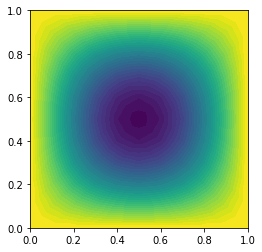

In [16]:
plot(u_old)

In [0]:
# 5. print the errors (and export the solution)

print('L2 = {:.4e}'.format(l2err))
print('H1 = {:.4e}'.format(h1err))

vtkfile = File('ex01.pvd')
vtkfile << (u_old, Tfin)

L2 = 5.7638e+26
H1 = 4.7138e+28


### Results

Convergence in time (with fixed $n=10$) 

$$
\begin{array}{ccccc}
& \delta t & 0.1 & 0.01  & 0.0001\\
\theta=0 & L^2-\rm{error} &1.71\cdot 10^{24}& inf & 1.9\cdot 10^{-3} \\
\theta=0 & H^1-\rm{error} &1.43\cdot 10^{26}& inf & 9.19\cdot 10^{-2} \\
& & & & \\
& \delta t & 0.1 & 0.01  & 0.0001\\
\theta=1 & L^2-\rm{error} &7.66\cdot 10^{-2}& &  \\
\theta=1 & H^1-\rm{error} &3.41\cdot 10^{-1}& &  \\
& & & & \\
& \delta t & 0.1 & 0.01  & 0.0001\\
\theta=0.5 & L^2-\rm{error} &1.94\cdot 10^{-3}& 1.91\cdot 10^{-3}&  \\
\theta=0.5 & H^1-\rm{error} &9.19\cdot 10^{-2}& 9.19\cdot 10^{-2} &  \\
\end{array}
$$

Convergence in space (with fixed $\delta t = 0.01$)

$$
\begin{array}{cccccc}
& n & 5 & 10  & 20 & 40\\
\theta=0 & L^2-\rm{error} &-& &  \\
\theta=0 & H^1-\rm{error} &-& &  \\
& & & & \\
\theta=1 & L^2-\rm{error} &-& &  \\
\theta=1 & H^1-\rm{error} &-& &  \\
& & & & \\
\theta=0.5 & L^2-\rm{error} &-& &  \\
\theta=0.5 & H^1-\rm{error} &-& &  \\
\end{array}
$$

#### **Exercise 1**: Repeat the previous numerical analysis of the considered schemes by using a for loop on the different values of $\delta t$. For each of the values of $\theta$ compute the corresponding convergence rates.

#### **Exercise 2**: Confirm numerically the second-order space-time convergence behavior of the scheme obtained by taking $\theta = 0.5$ and the lagrangian $\mathbb{P}^2$ finite element space (spanned by continuous piecewise quadratic polynomials). To evaluate the convergence perform 4 successive refinements taking $n_{i+1}= 2 n_i$ and $\delta t_{i+1}= \frac12\delta t_{i}$.